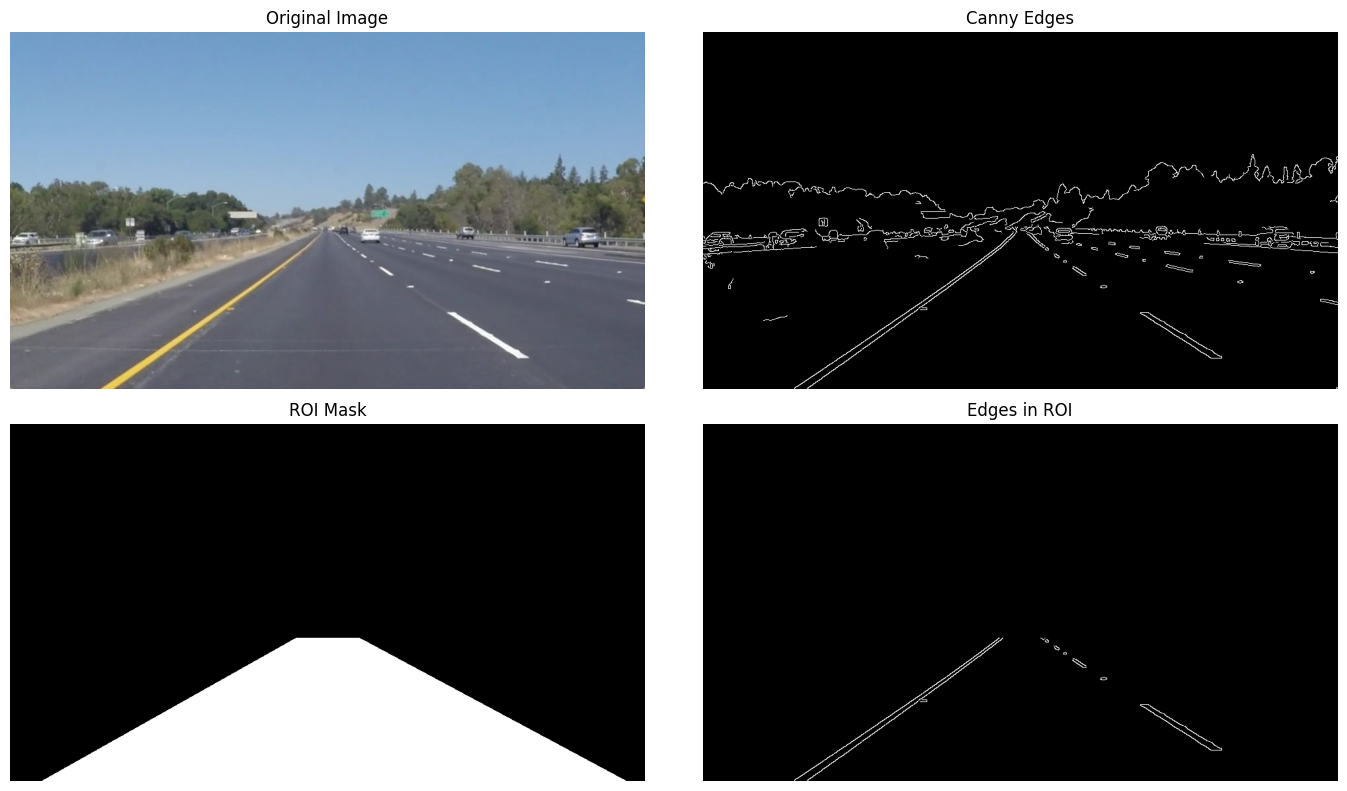

Lines found: 10


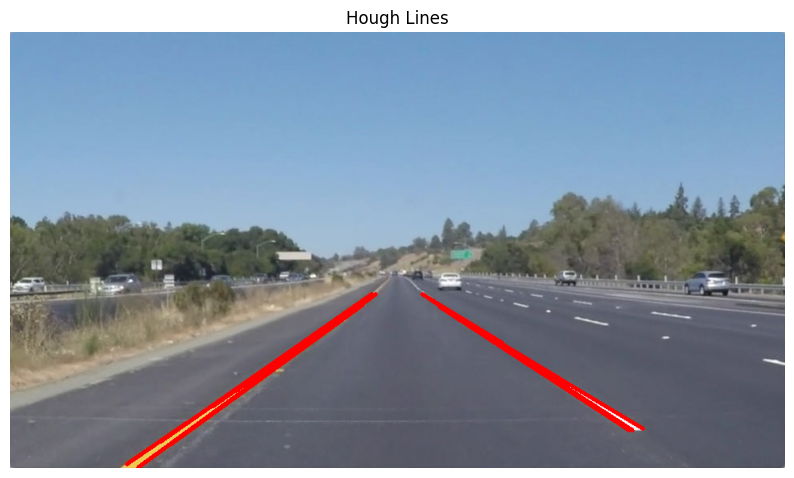

Left lane: (145, 540, 436, 334)
Right lane: (849, 540, 525, 334)


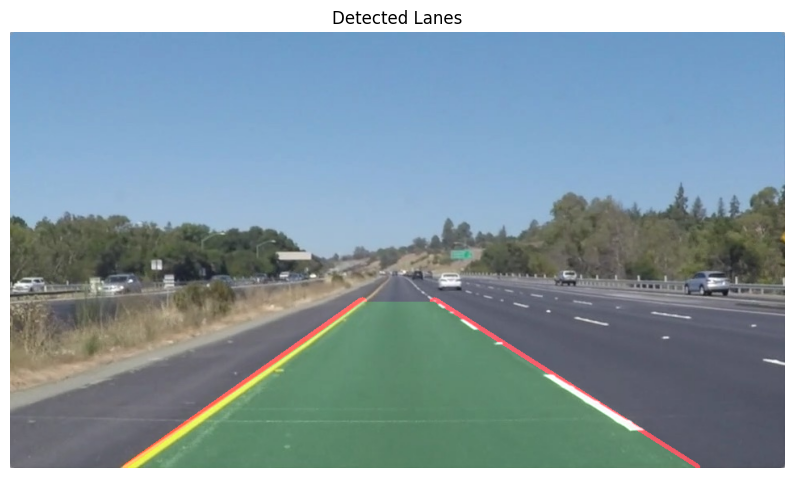

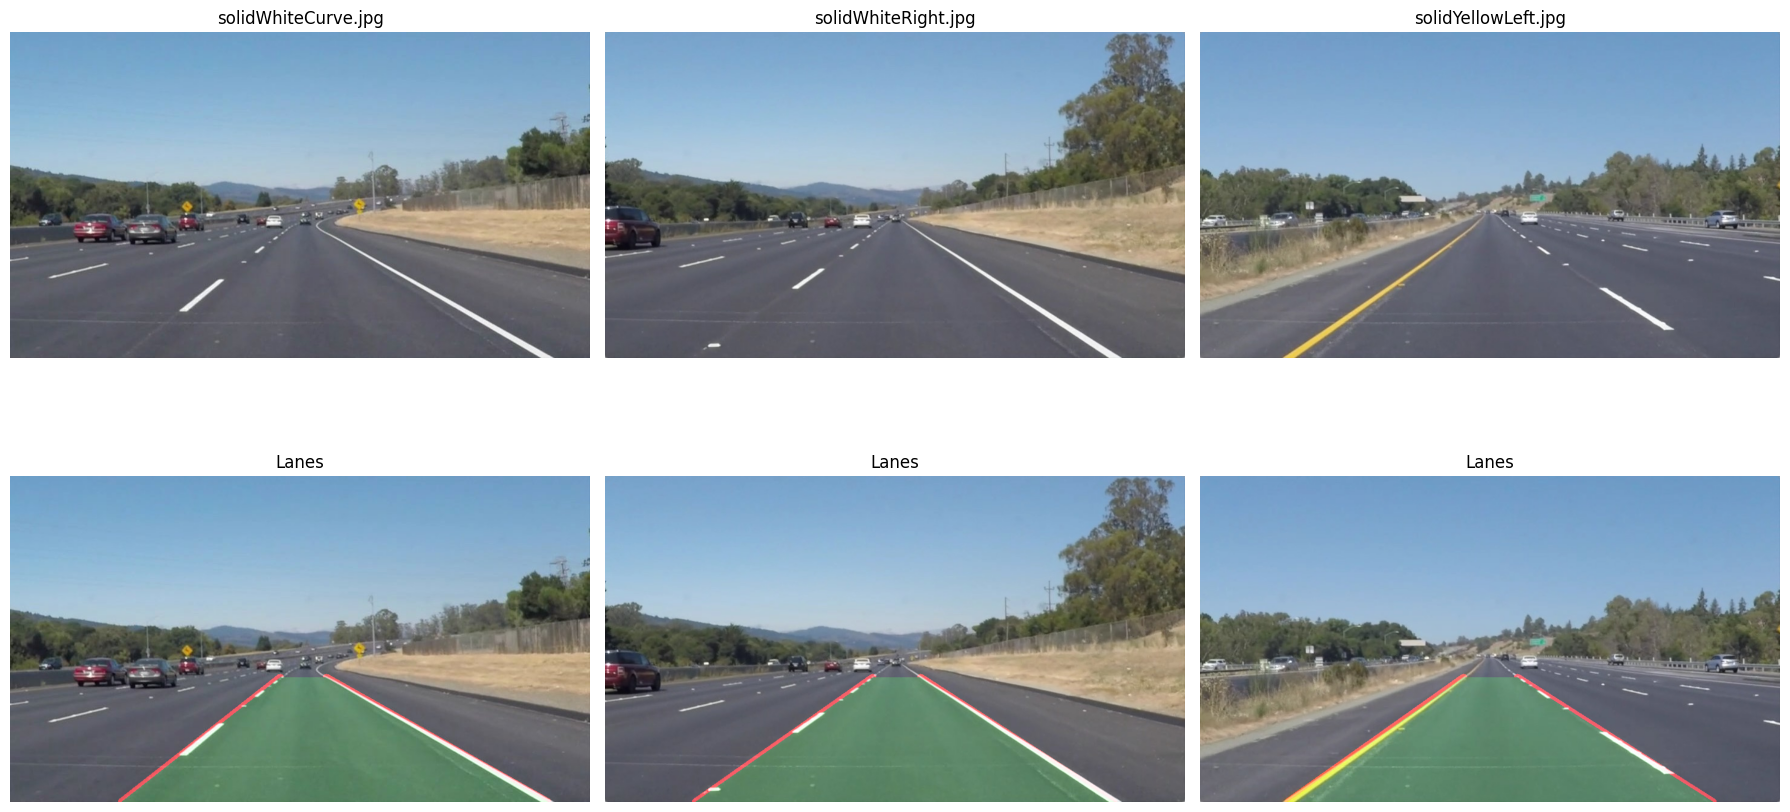

Total frames: 221
Both lanes found in: 221 frames


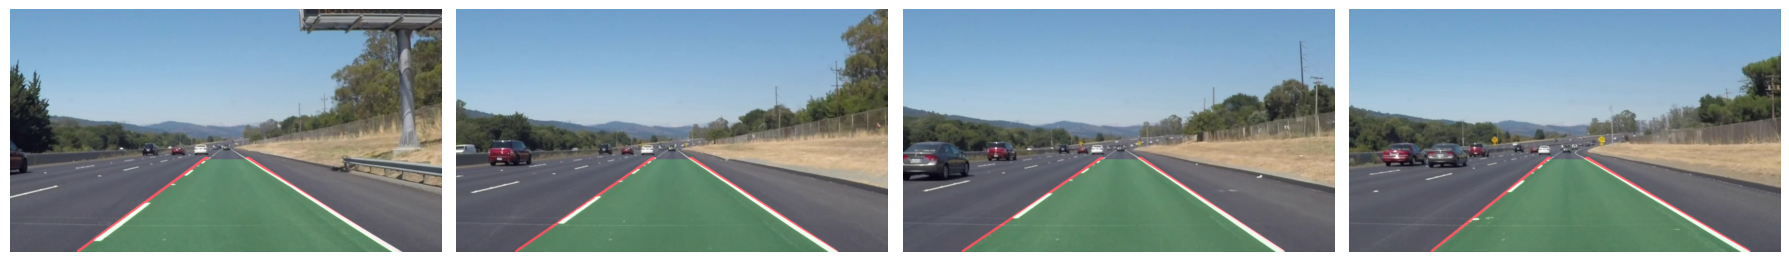

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
image = cv2.imread("solidYellowLeft.jpg")
if image is None:
    print("Image not found, check the path")

# Convert BGR to RGB for Matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Gaussian blur
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Canny edge detection
edges = cv2.Canny(blurred, 50, 150)

# Region of interest (only the road in front of the car)
h, w = gray.shape
roi_points = np.array([[(int(0.05 * w), h), (int(0.45 * w), int(0.6 * h)),
                        (int(0.55 * w), int(0.6 * h)), (int(0.97 * w), h)]], np.int32)
mask = np.zeros_like(edges)
cv2.fillPoly(mask, roi_points, 255)
roi_edges = cv2.bitwise_and(edges, mask)

plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(mask, cmap="gray")
plt.title("ROI Mask")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(roi_edges, cmap="gray")
plt.title("Edges in ROI")
plt.axis("off")

plt.tight_layout()
plt.show()

# Hough line transform
lines = cv2.HoughLinesP(roi_edges, 2, np.pi / 180, 40, minLineLength=30, maxLineGap=150)
lines = lines.reshape(-1, 4)
print("Lines found:", len(lines))

# Draw all hough lines
line_image = image_rgb.copy()
for x1, y1, x2, y2 in lines:
    cv2.line(line_image, (x1, y1), (x2, y2), (255, 0, 0), 3)

plt.figure(figsize=(10, 6))
plt.imshow(line_image)
plt.title("Hough Lines")
plt.axis("off")
plt.show()

# make one left line and one right line
# left lane has negative slope, right lane has positive slope
def average_lines(lines, h):
    top = int(0.62 * h)
    left_x = []
    left_y = []
    right_x = []
    right_y = []

    for x1, y1, x2, y2 in lines:
        if x1 == x2:
            continue
        slope = (y2 - y1) / (x2 - x1)
        if slope < -0.5:
            left_x += [x1, x2]
            left_y += [y1, y2]
        elif slope > 0.5:
            right_x += [x1, x2]
            right_y += [y1, y2]

    left_line = None
    right_line = None

    if len(left_x) > 0:
        a, b = np.polyfit(left_y, left_x, 1)   # x = a*y + b
        left_line = (int(a * h + b), h, int(a * top + b), top)

    if len(right_x) > 0:
        a, b = np.polyfit(right_y, right_x, 1)
        right_line = (int(a * h + b), h, int(a * top + b), top)

    return left_line, right_line

# draw lane lines and fill the lane in green
def draw_lanes(image, left_line, right_line):
    layer = np.zeros_like(image)
    if left_line is not None:
        cv2.line(layer, (left_line[0], left_line[1]), (left_line[2], left_line[3]), (0, 0, 255), 12)
    if right_line is not None:
        cv2.line(layer, (right_line[0], right_line[1]), (right_line[2], right_line[3]), (0, 0, 255), 12)
    if left_line is not None and right_line is not None:
        points = np.array([[(left_line[0], left_line[1]), (left_line[2], left_line[3]),
                            (right_line[2], right_line[3]), (right_line[0], right_line[1])]], np.int32)
        cv2.fillPoly(layer, points, (0, 70, 0))
    return cv2.addWeighted(image, 1, layer, 0.6, 0)

left_line, right_line = average_lines(lines, h)
print("Left lane:", left_line)
print("Right lane:", right_line)

result = draw_lanes(image, left_line, right_line)
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Detected Lanes")
plt.axis("off")
plt.show()

# full lane detection for any image
def lane_detection(image):
    h, w = image.shape[:2]
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 50, 150)

    roi_points = np.array([[(int(0.05 * w), h), (int(0.45 * w), int(0.6 * h)),
                            (int(0.55 * w), int(0.6 * h)), (int(0.97 * w), h)]], np.int32)
    mask = np.zeros_like(edges)
    cv2.fillPoly(mask, roi_points, 255)
    roi_edges = cv2.bitwise_and(edges, mask)

    lines = cv2.HoughLinesP(roi_edges, 2, np.pi / 180, 40, minLineLength=30, maxLineGap=150)
    if lines is None:
        return image, None, None
    left_line, right_line = average_lines(lines.reshape(-1, 4), h)
    return draw_lanes(image, left_line, right_line), left_line, right_line

# Test on all 3 images
files = ["solidWhiteCurve.jpg", "solidWhiteRight.jpg", "solidYellowLeft.jpg"]

plt.figure(figsize=(18, 10))
for i in range(3):
    img = cv2.imread(files[i])
    result, left_line, right_line = lane_detection(img)

    plt.subplot(2, 3, i + 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(files[i])
    plt.axis("off")

    plt.subplot(2, 3, i + 4)
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title("Lanes")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Run on video
cap = cv2.VideoCapture("solidWhiteRight.mp4")
if not cap.isOpened():
    print("Video not found, check the path")

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter("lanes_video.mp4", cv2.VideoWriter_fourcc(*"mp4v"), fps, (width, height))

frame_count = 0
both_found = 0
saved_frames = []

while True:
    ret, frame = cap.read()
    if not ret:
        break

    result, left_line, right_line = lane_detection(frame)
    out.write(result)

    frame_count += 1
    if left_line is not None and right_line is not None:
        both_found += 1
    if frame_count in [1, 60, 120, 200]:
        saved_frames.append(result)

cap.release()
out.release()

print("Total frames:", frame_count)
print("Both lanes found in:", both_found, "frames")

plt.figure(figsize=(18, 4))
for i in range(len(saved_frames)):
    plt.subplot(1, 4, i + 1)
    plt.imshow(cv2.cvtColor(saved_frames[i], cv2.COLOR_BGR2RGB))
    plt.axis("off")
plt.tight_layout()
plt.show()